In [1]:
from pathlib import Path
import pandas as pd
import json
import pickle
import warnings
import shutil
import re, glob
import hdf5storage
from tqdm import tqdm
from copy import deepcopy
import numpy as np
import h5py

import importlib
# import utils.functions as func
# importlib.reload(func)
# from utils.functions import *
# import utils.pre_processing as pre_processing
# importlib.reload(pre_processing)
# from utils.pre_processing import symmetric_intensities #, radial_profile, radial_profile_2d, radial_profile_2d_masked


import tifffile
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.ndimage import map_coordinates
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
from matplotlib.legend_handler import HandlerTuple
from photutils.aperture import RectangularAnnulus
from photutils.detection import find_peaks

# from hcipy import Field, make_pupil_grid, get_strehl_from_focal, radial_profile
from applefy_extensions.contrast_curves import ContrastFast
from applefy.statistics import TTest, gaussian_sigma_2_fpf, fpf_2_gaussian_sigma
from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.utils.file_handling import save_as_fits
from applefy.utils.contrast_grid import compute_contrast_from_grid
from applefy.utils.positions import center_subpixel



from fours.utils.data_handling import read_fours_root_dir
from fours.utils.setups import contrast_grid_setup_1
from fours.detection_limits.applefy_wrapper import CADIDataReductionGPU, PCADataReductionGPU
from fours.detection_limits.applefy_wrapper import FourSDataReduction
from fours.models.psf_subtraction import FourS


from pipeline_pre_ADI.pre_process.plot_pre_processing import *

from pipeline_pre_ADI.pre_process.pre_processing import *

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Waffle Mode

In [2]:
psf_file = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/pred_10ro_20ws_no_coro_2026-08-25T15-58'
img_file = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/pred_10ro_20ws_coro_2026-08-25T15-56-02.473_'
psf_img = tiff.imread(glob.glob(f"{psf_file}*.tif"), 
                        key=range(10000) 
                        )


sci_img = tiff.imread(glob.glob(f"{img_file}*.tif"), 
                        key=range(9978) 
                        )

In [ ]:
def find_satellite_speckles(
    image,
    w_in,
    w_out,
    n_speckles=6,
    min_distance=10,
):
    """
    Find the brightest satellite speckles inside a rectangular annulus.

    Parameters
    ----------
    image : 2D ndarray
        Input image.

    center : tuple
        (x, y) position of the central source.

    w_in : float
        Inner rectangle width.

    w_out : float
        Outer rectangle width.

    n_speckles : int
        Number of speckles to return.

    min_distance : int
        Minimum separation between detected peaks in pixels.

    Returns
    -------
    speckles : list of dict
        Detected speckles sorted by brightness.

    """

    # --------------------------------------------------
    # Create rectangular annulus
    # --------------------------------------------------
    center = center_subpixel(image)
    aperture = RectangularAnnulus(
        positions=center,
        w_in=w_out - 5,
        w_out=w_out,
        h_out=w_out,
        h_in=w_in,
    )

    # --------------------------------------------------
    # Create aperture mask
    # --------------------------------------------------

    mask = aperture.to_mask(method="center")

    aperture_mask = mask.to_image(image.shape)

    # Pixels outside the rectangular annulus
    masked_image = np.where(
        aperture_mask > 0,
        image,
        np.nan
    )

    # --------------------------------------------------
    # Find local maxima
    # --------------------------------------------------

    peaks = find_peaks(
        masked_image,
        threshold=np.nanmin(masked_image),
        box_size=2 * min_distance + 1,
        mask=~np.isfinite(masked_image),
    )

    if peaks is None:
        return [], aperture

    # --------------------------------------------------
    # Sort by peak brightness
    # --------------------------------------------------

    peaks.sort(
        "peak_value",
        reverse=True
    )

    # --------------------------------------------------
    # Select brightest separated peaks
    # --------------------------------------------------

    speckles = []

    for peak in peaks:

        x = float(peak["x_peak"])
        y = float(peak["y_peak"])
        brightness = float(peak["peak_value"])

        # Enforce minimum separation
        too_close = any(
            np.hypot(
                x - s["x"],
                y - s["y"]
            ) < min_distance
            for s in speckles
        )

        if too_close:
            continue

        speckles.append({
            "x": x,
            "y": y,
            "brightness": brightness,
        })

        if len(speckles) >= n_speckles:
            break

    return speckles, aperture_mask





def plot_speckles(
    image,
    speckles,
    circle_radius=8,
    cmap="inferno",
    vmin=None,
    vmax=None,
):
    """
    Plot an image with detected speckles marked by red circles
    and numbered labels.

    Parameters
    ----------
    image : 2D ndarray
        Input image.

    speckles : list of dict
        Output from find_brightest_speckles().
        Each dict must contain 'x' and 'y'.

    figsize : tuple
        Figure size.

    circle_radius : float
        Radius of the red circles in pixels.

    cmap : str
        Matplotlib colormap.

    vmin, vmax : float, optional
        Display limits for the image.
    """

    # --------------------------------------------------
    # Display image
    # --------------------------------------------------

    plt.imshow(
        image,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar()

    # --------------------------------------------------
    # Plot speckles
    # --------------------------------------------------

    for i, speckle in enumerate(speckles, start=1):

        x = speckle["x"]
        y = speckle["y"]

        # Red circle
        circle = Circle(
            (x, y),
            radius=circle_radius,
            edgecolor="red",
            facecolor="none",
            linewidth=2,
        )

        plt.gca().add_patch(circle)

        # Number next to speckle
        plt.text(
            x + circle_radius + 3,
            y + circle_radius + 3,
            str(i),
            color="red",
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="bottom",
        )

    plt.xlabel("X [pixel]")
    plt.ylabel("Y [pixel]")

    #plt.title(f"Six brightest satellite speckles")

    plt.tight_layout()



In [4]:
def plot_center(speckles,
                circle_radius = 8
                ):
    center_x = np.mean([p['x'] for p in speckles])
    center_y = np.mean([p['y'] for p in speckles])

    circle = Circle(
            (center_x, center_y),
            radius=circle_radius,
            edgecolor="red",
            facecolor="none",
            linewidth=2,
        )

    plt.gca().add_patch(circle)

Text(0.5, 1.0, 'Non - Coronographic Image')

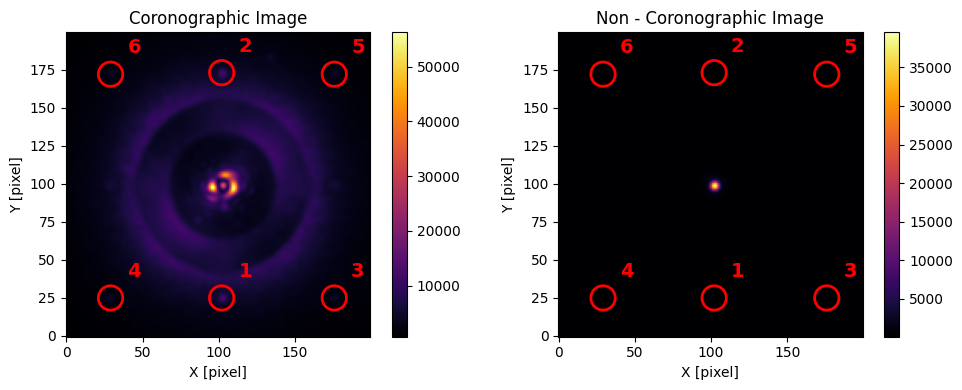

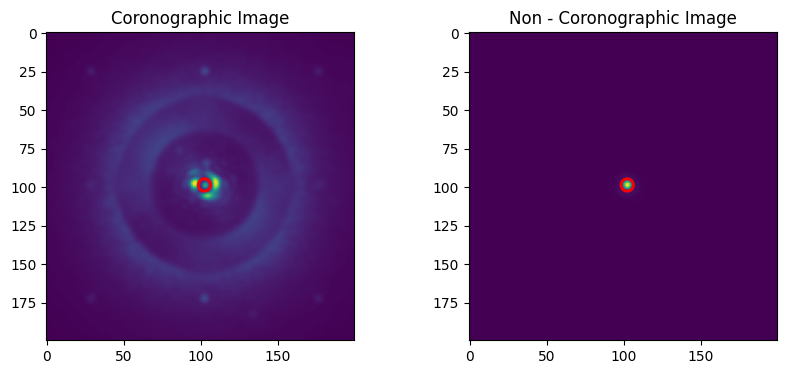

In [ ]:
speckles_img, aperture_mask_img = find_satellite_speckles(
    np.mean(sci_img, axis = 0),
    135,
    170,
    n_speckles=6,
    min_distance=30)

speckles_psf, aperture_mask_psf = find_satellite_speckles(
    np.mean(sci_img, axis = 0),
    135,
    170,
    n_speckles=6,
    min_distance=30)


plt.figure(figsize = (10, 4))
plt.subplot(121)
plot_speckles(
    np.mean(sci_img, axis = 0) * aperture_mask_img,
    speckles_img,
    circle_radius=8,
    cmap="inferno",
    vmin=None,
    vmax=None,
)
plt.title('Coronographic Image')

plt.subplot(122)
plot_speckles(
    np.mean(psf_img, axis = 0) * aperture_mask_psf,
    speckles_psf,
    circle_radius=8,
    cmap="inferno",
    vmin=None,
    vmax=None,
)
plt.title('Non - Coronographic Image')


plt.figure(figsize = (10, 4))
plt.subplot(121)
plt.imshow(
    np.mean(sci_img, axis = 0)
)
plot_center(speckles_img,
                circle_radius = 4)
plt.title('Coronographic Image')

plt.subplot(122)
plt.imshow(
    np.mean(psf_img, axis = 0)) 
plot_center(speckles_psf,
                circle_radius = 4)
plt.title('Non - Coronographic Image')

In [9]:
def print_centers(speckles):
    center_x = np.mean([p['x'] for p in speckles])
    center_y = np.mean([p['y'] for p in speckles])

    print('center_x: ', center_x)
    print('center_y: ', center_y)

    return (center_x, center_y)

In [ ]:
#print(np.shape(sci_img), np.shape(aperture_mask_psf), np.shape(aperture_mask_img * sci_img))

stacked_img = align_stack(images = sci_img, ref_array = aperture_mask_img * sci_img)
stacked_psf = align_stack(images = psf_img, ref_array = aperture_mask_psf * psf_img)


(9978, 200, 200) (200, 200) (9978, 200, 200)


In [8]:
speckles_img_stacked, _ = find_satellite_speckles(
    np.mean(stacked_img, axis = 0),
    135,
    170,
    n_speckles=6,
    min_distance=30)

speckles_psf_stacked, _ = find_satellite_speckles(
    np.mean(stacked_psf, axis = 0),
    135,
    170,
    n_speckles=2,
    min_distance=30)

In [9]:
print('CORONOGRAPHIC:')
print('Aligned')
print_centers(speckles_img_stacked)
print('Mean')
print_centers(speckles_img)

print('\nNON-CORONOGRAPHIC:')
print('Aligned')
print_centers(speckles_psf_stacked)
print('Mean')
print_centers(speckles_psf)

CORONOGRAPHIC:
Aligned
center_x:  102.33333333333333
center_y:  98.66666666666667
Mean
center_x:  102.33333333333333
center_y:  98.66666666666667

NON-CORONOGRAPHIC:
Aligned
center_x:  102.5
center_y:  99.0
Mean
center_x:  102.33333333333333
center_y:  98.66666666666667


(np.float64(102.33333333333333), np.float64(98.66666666666667))

In [10]:
def center_all( tuple_center, aligned_stack, half = 20):
    xc, yc = tuple_center
    center_y = int(np.floor(float(yc) + 0.5))
    center_x = int(np.floor(float(xc) + 0.5))

    # Shift required to move (cy, cx) -> (target_y, target_x)
    dy = center_y - yc
    dx = center_x - xc

    aligned_shifted = shift(
        aligned_stack,
        shift=(0, dy, dx),
        order=3,
        mode="constant",
        cval=0,
    )
    cropped = aligned_shifted[
        :,
        center_y - half : center_y + half + 1,
        center_x - half : center_x + half + 1
    ]
    return cropped, (center_x, center_y)

Text(0.5, 1.0, 'Non - Coronographic Image')

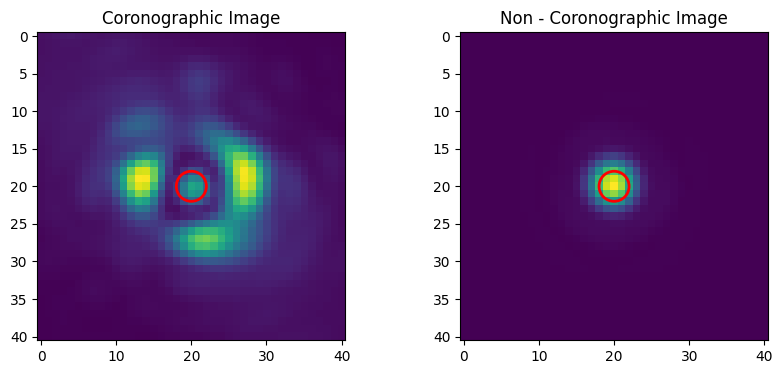

In [ ]:
aligned_shifted_img, center_tuple_img =  center_all(print_centers(speckles_img_stacked), stacked_img)
aligned_shifted_psf, center_tuple_psf =  center_all(print_centers(speckles_psf_stacked), stacked_psf)


plt.figure(figsize = (10, 4))
plt.subplot(121)
plt.imshow(
    np.mean(aligned_shifted_img, axis = 0)
)
plt.gca().add_patch(Circle(
        (20,20),
        radius=2,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    ))
plt.title('Coronographic Image')

plt.subplot(122)
plt.imshow(
    np.mean(aligned_shifted_psf, axis = 0)) 
plt.gca().add_patch(Circle(
        (20,20),
        radius=2,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    ))
plt.title('Non - Coronographic Image')

# More Speckle Linearity Statistics

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


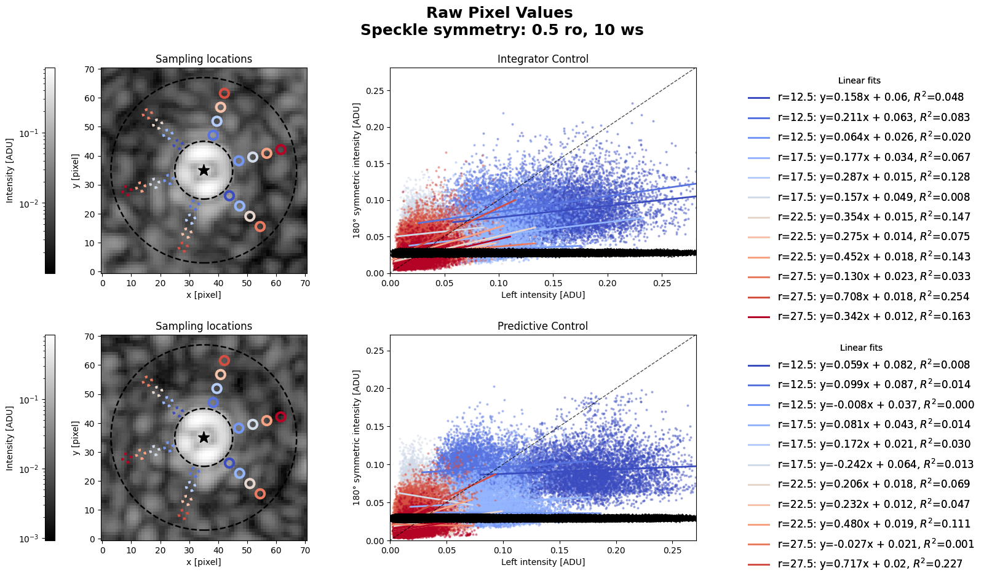

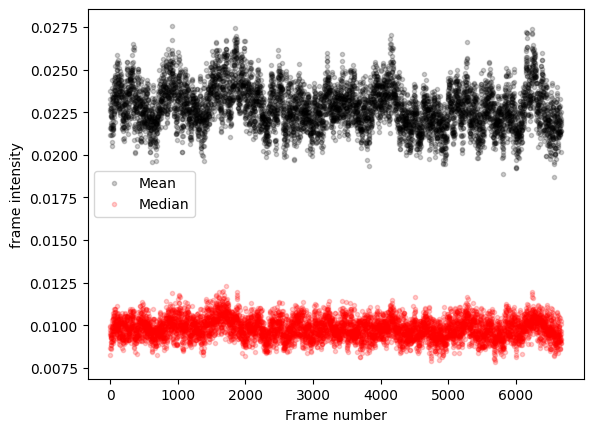

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


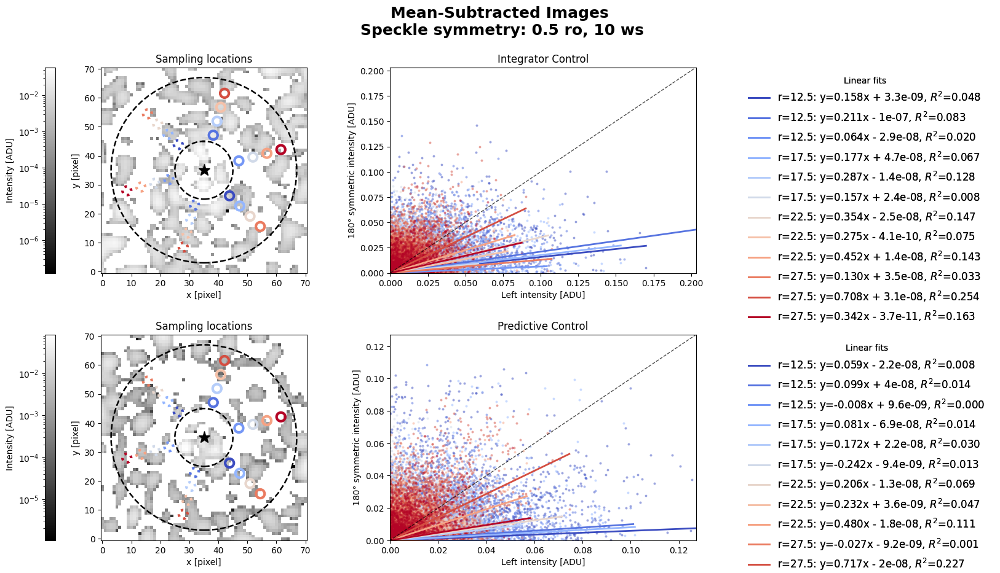

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


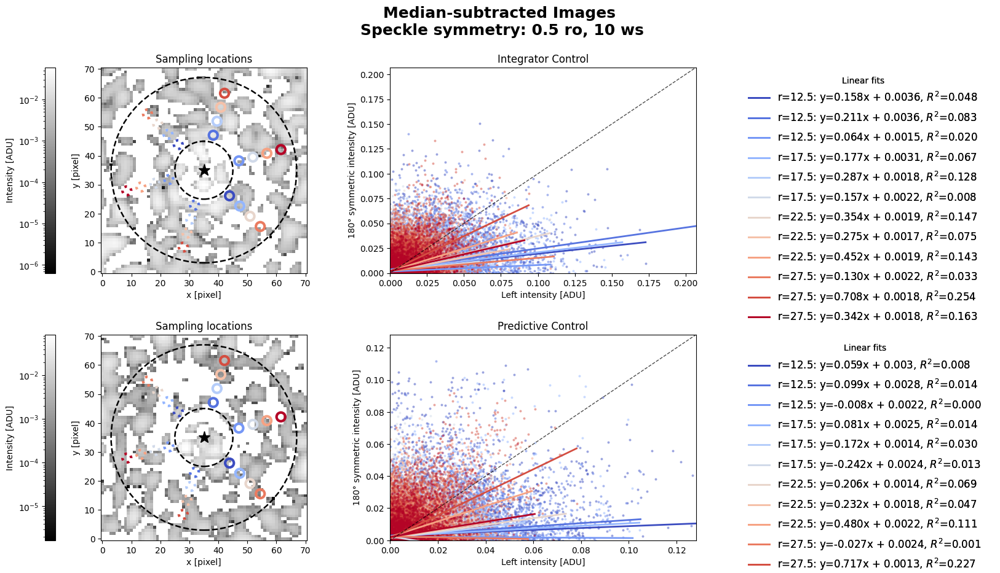

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


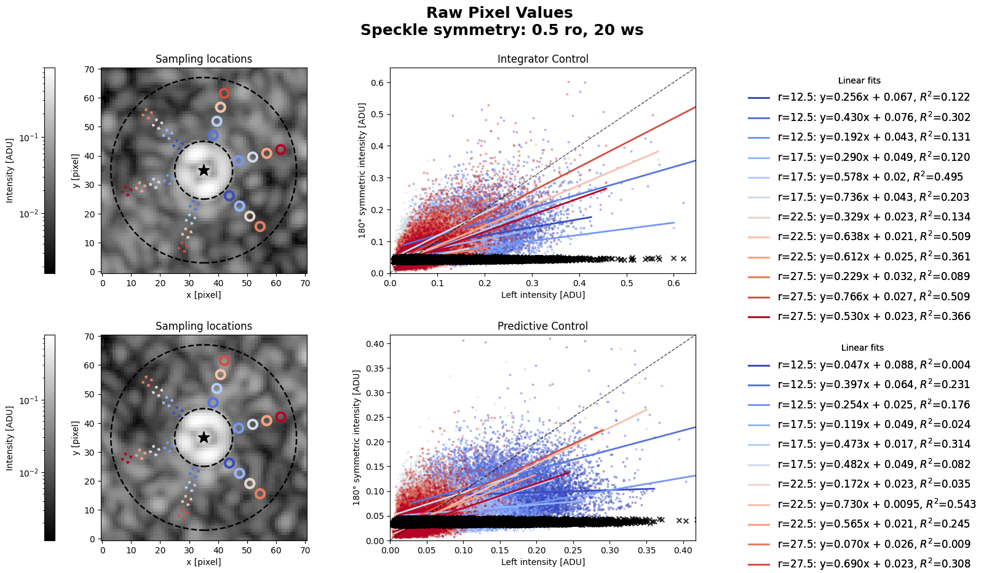

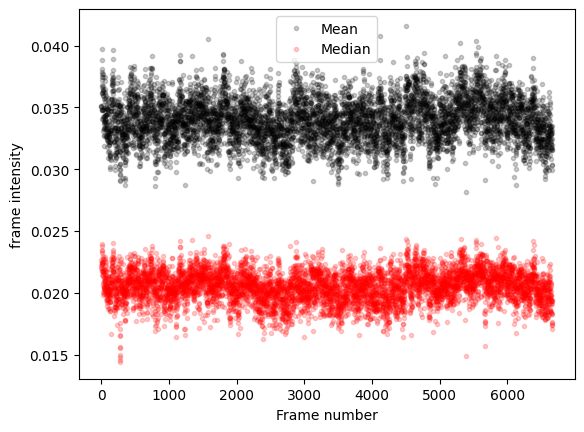

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


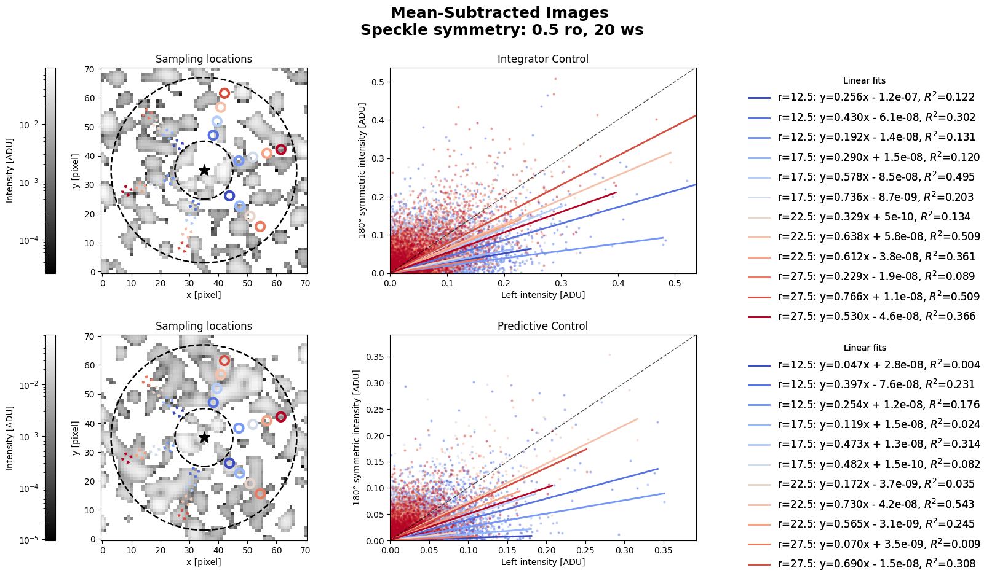

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


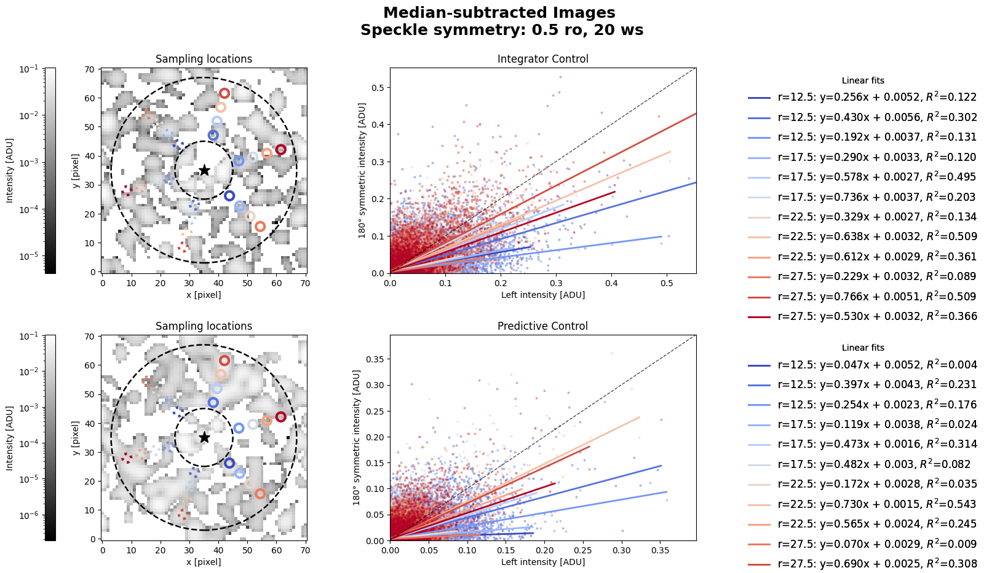

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


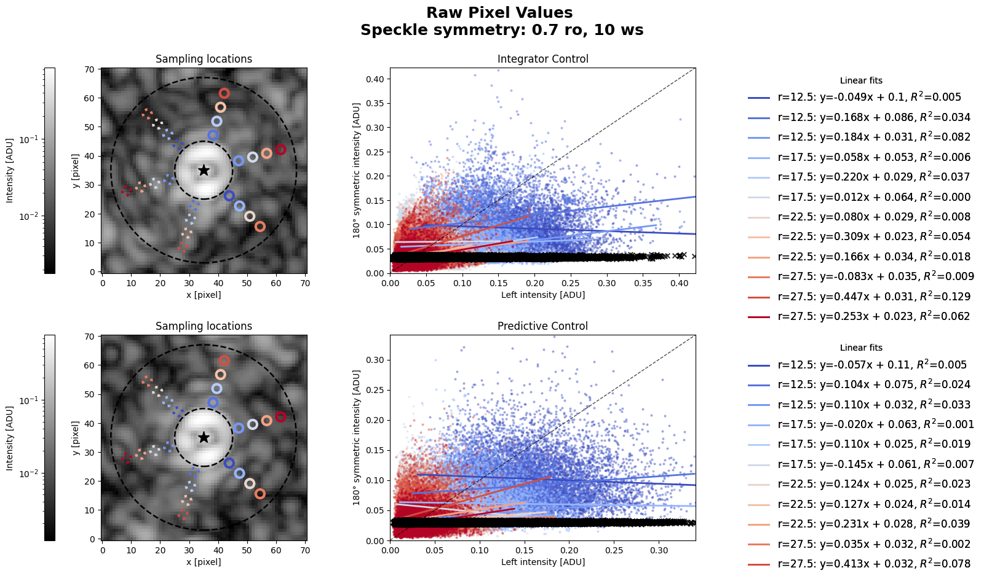

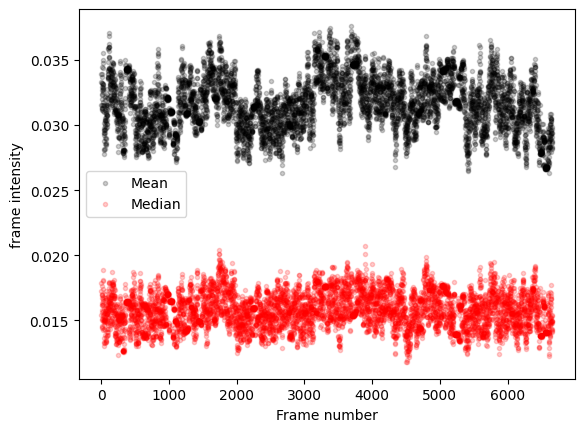

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


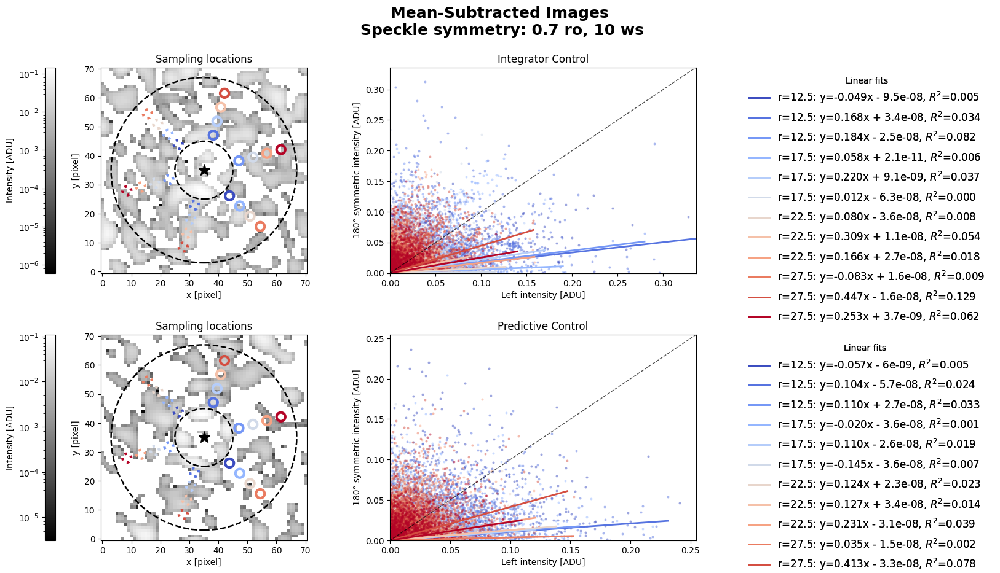

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


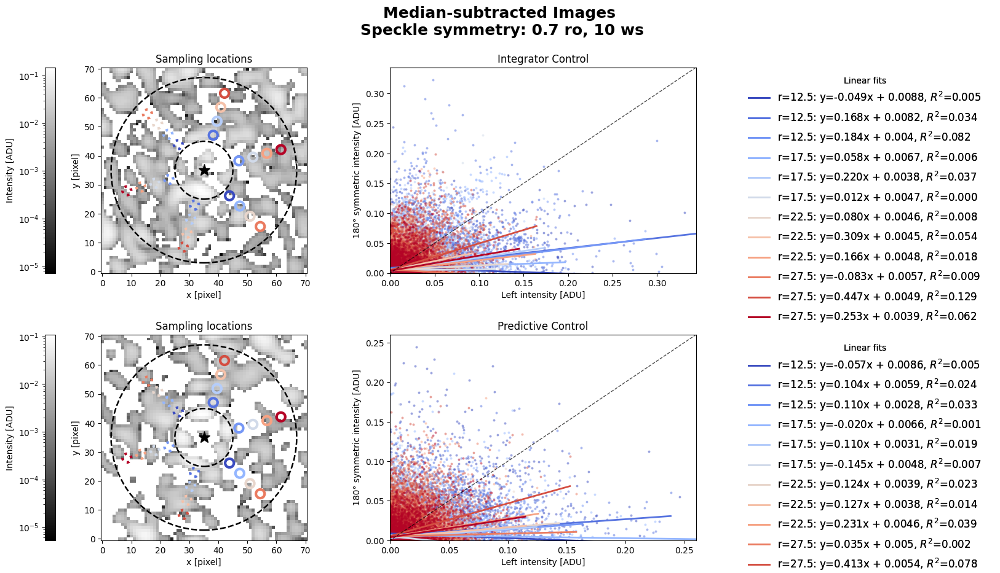

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


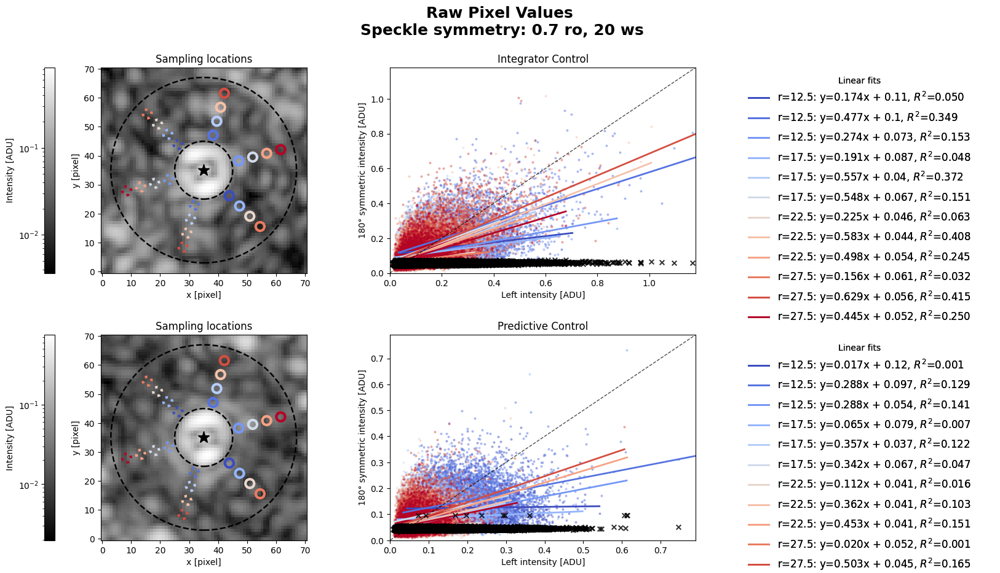

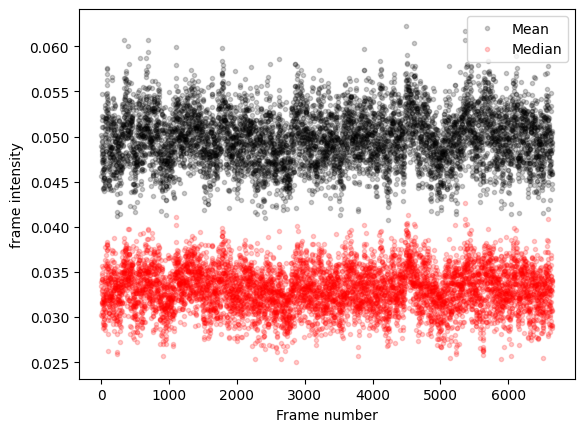

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


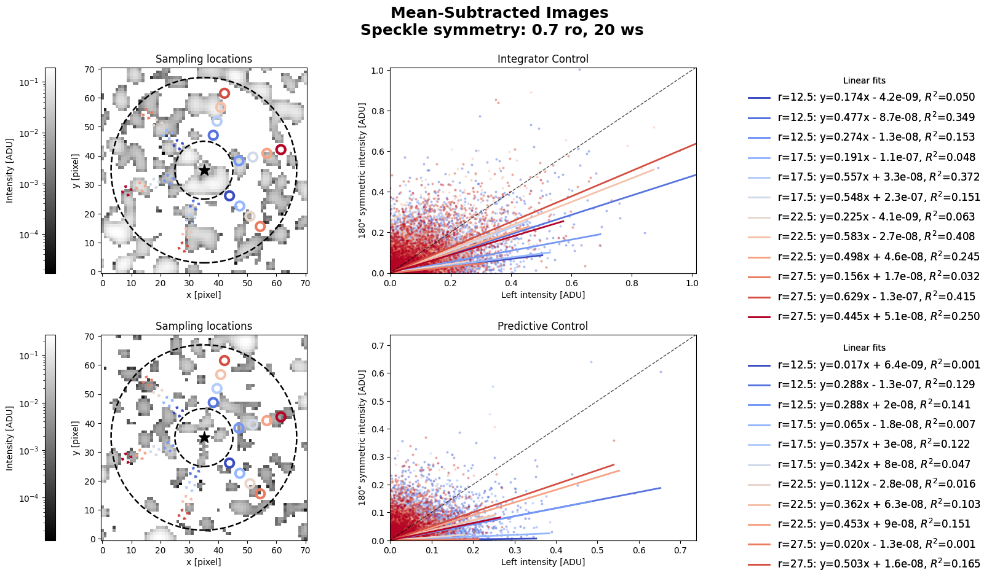

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


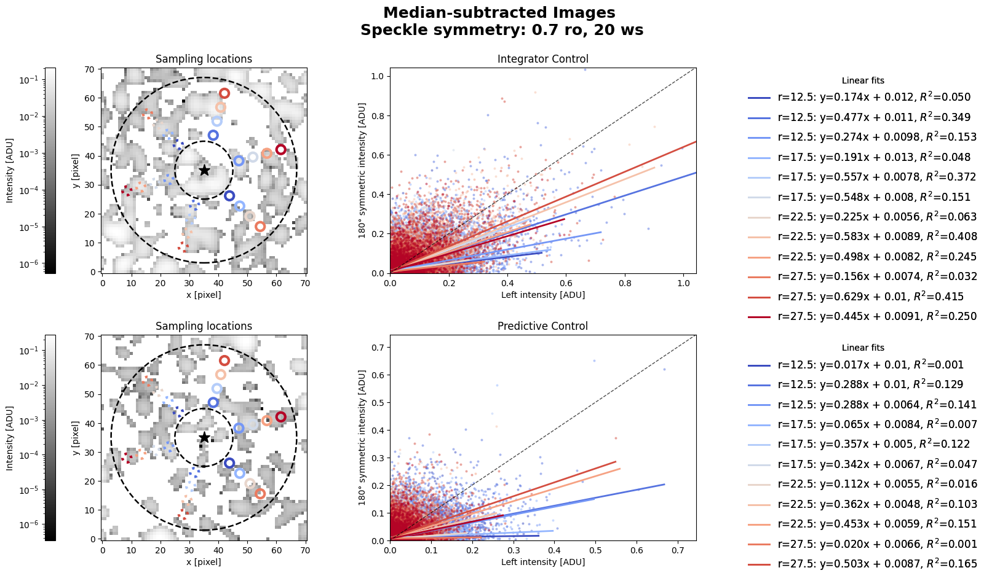

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


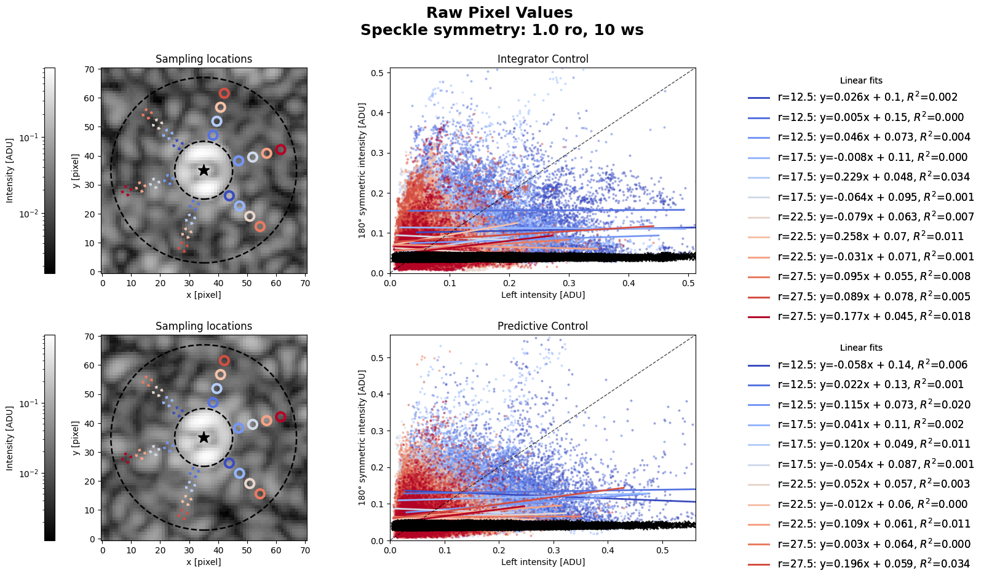

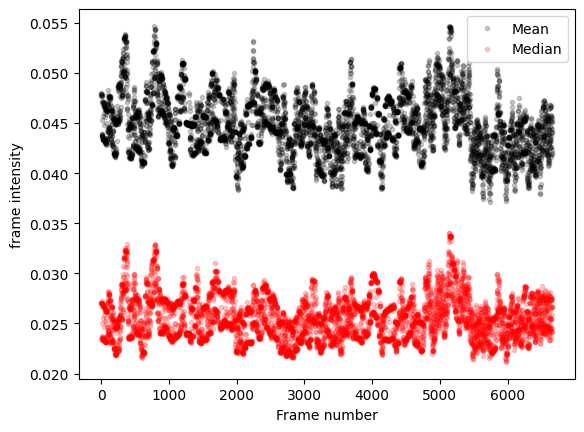

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


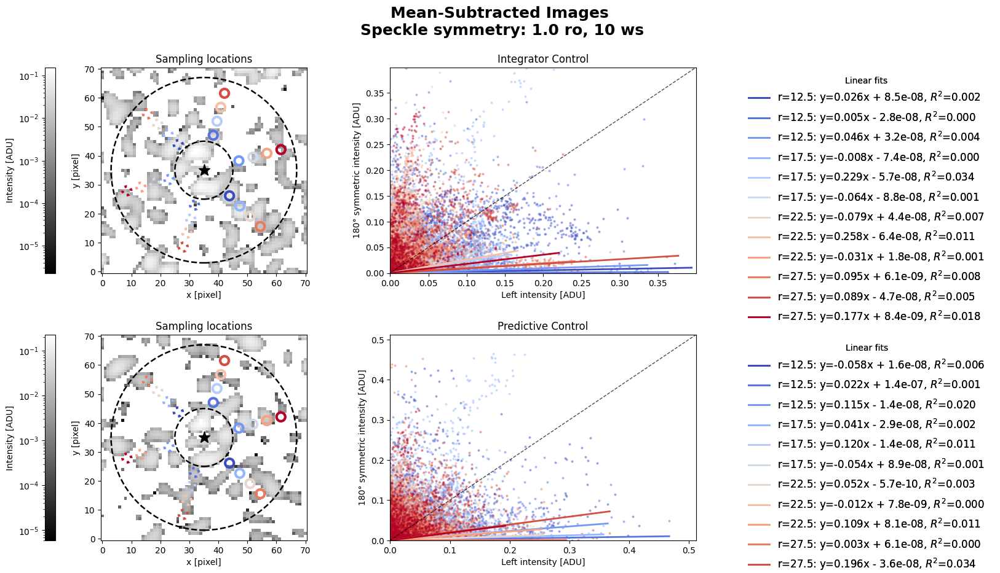

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


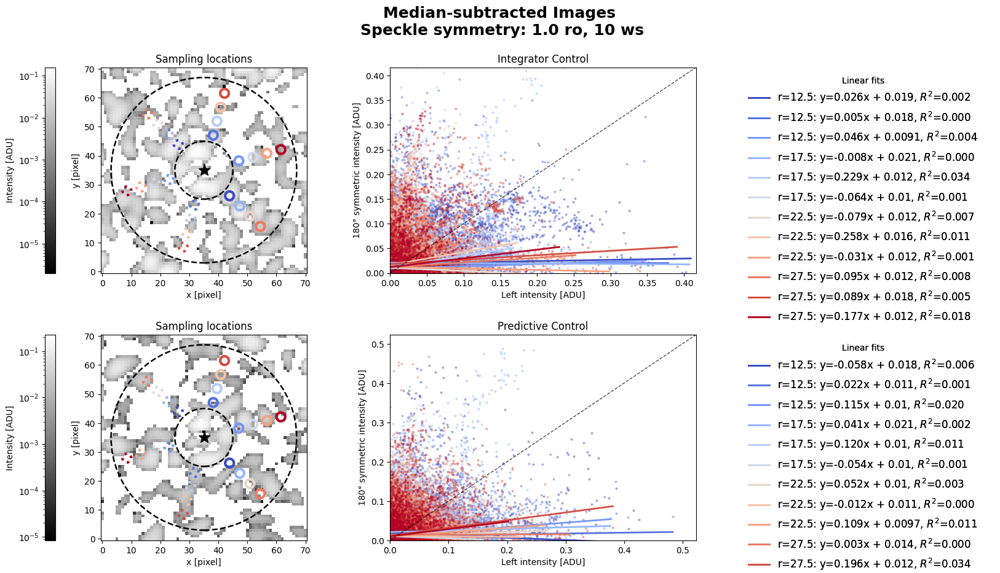

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


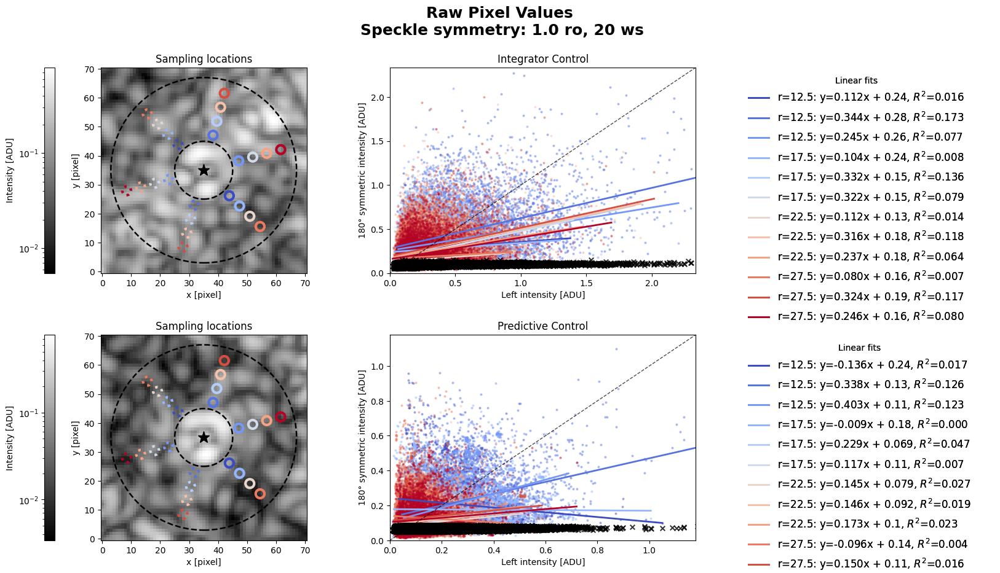

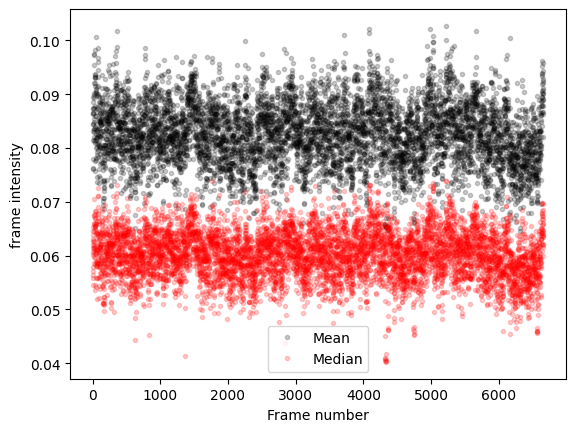

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


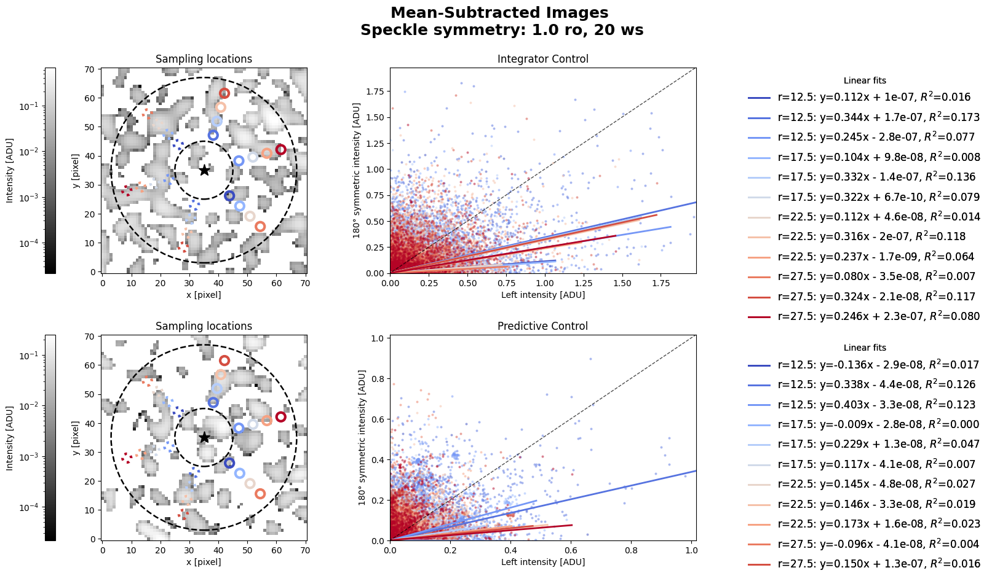

/home/aosimul/noah/src/pipeline_pre_ADI/pre_process/plot_pre_processing.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


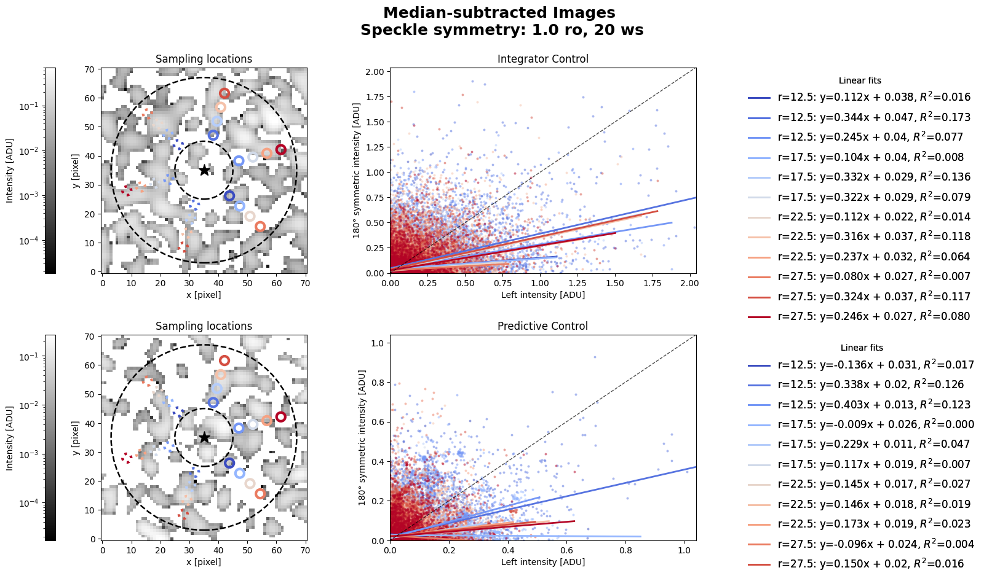

In [ ]:
ori_path = '/home/aosimul/noah/data/ghost_images/10_20ws/'
ro = 0.5
ws = 10
inner_rad=10
outer_rad=32
dr=5.0
crop=20 
aperture_radius=1.5 
# (
#     (x1, y1),
#     left_int,
#     (x2, y2),
#     symmetric_int, 
#     radii
# ) = symmetric_intensities(
#     int_cube,
#     [-45.0, 75.0, 15.0],
#     inner_rad,
#     outer_rad,
#     dr=3,
#     r_aperture = 1
# )


for ro in [0.5, 0.7, 1.0]:
    for ws in [10, 20]:
        name = f"{ro}ro_{ws}ws" 
        int_cube = np.load( f"{ori_path}int_{name}.npy" ) 
        pred_cube = np.load( f"{ori_path}pred_{name}.npy" ) 


        fig, fit_results = plot_symmetric_comparison( 
                            int_cube, pred_cube, 
                            skip = 1,
                            plot_frame_mean= True,
                            suptitle=f"Raw Pixel Values \nSpeckle symmetry: {ro} ro, {ws} ws", 
                            angle=[-45.0, 75.0, 15.0], 
                            dr = 3, 
                            r_aperture = 1) 
        plt.show()

        plt.plot(np.arange(len(int_cube)), np.mean(int_cube, axis = (1,2)), '.', color ='black', alpha = 0.2, label = 'Mean')

        plt.plot(np.arange(len(int_cube)), np.median(int_cube, axis = (1,2)), '.', color ='red', alpha = 0.2, label = 'Median')
        plt.ylabel('frame intensity')
        plt.xlabel('Frame number')
        plt.legend()
        plt.show()

        int_cube_sub = int_cube - np.mean(int_cube, axis = 0)
        pred_cube_sub = pred_cube - np.mean(pred_cube, axis = 0)
        fig, fit_results = plot_symmetric_comparison( 
                            int_cube_sub, pred_cube_sub, 
                            skip = 1,
                            plot_frame_mean= False,
                            suptitle=f"Mean-Subtracted Images \nSpeckle symmetry: {ro} ro, {ws} ws", 
                            angle=[-45.0, 75.0, 15.0], 
                            dr = 3, 
                            r_aperture = 1) 
        plt.show()

        int_cube_sub_med = int_cube - np.median(int_cube, axis = 0)
        pred_cube_sub_med = pred_cube - np.median(pred_cube, axis = 0)
        fig, fit_results = plot_symmetric_comparison( 
                            int_cube_sub_med, pred_cube_sub_med, 
                            skip = 1,
                            plot_frame_mean= False,
                            suptitle=f"Median-subtracted Images \nSpeckle symmetry: {ro} ro, {ws} ws", 
                            angle=[-45.0, 75.0, 15.0], 
                            dr = 3, 
                            r_aperture = 1) 
        plt.show()

In [30]:
ori_path = '/home/aosimul/noah/data/ghost_images/10_20ws/'
inner_rad=5
outer_rad=40
dr=1
crop=15 
photometry_radius=1.0 
angle = [-75.0, -45.0, -15.0, 15.0, 45.0, 75.0]
# (
#     (x1, y1),
#     left_int,
#     (x2, y2),
#     symmetric_int, 
#     radii
# ) = symmetric_intensities(
#     int_cube,
#     [-45.0, 75.0, 15.0],
#     inner_rad,
#     outer_rad,
#     dr=3,
#     r_aperture = 1
# )

fontsize = 12
width_ratios = [1, 1]

results = []

for ro in [0.5, 0.7, 1.0]:
    # fig = plt.figure(figsize=(20, 10))

    # gs = fig.add_gridspec(
    #     2,
    #     2,
    #     width_ratios= width_ratios,
    #     wspace=0.15,
    #     hspace=0.3,
    # )
    
    for i, ao in enumerate(['int','pred']):
        # ax_mi = fig.add_subplot(gs[i, 0])
        # ax_pc = fig.add_subplot(gs[i, 1])

        # ax_mi.set_title('                                                       Integrative Control Loop Statistics' 
        #                 if ao =='int' 
        #                 else 
        #                 '                                                       Predictive Control Loop Statistics', 
        #                 fontsize = 15)
        # ax_mi.set_xlabel('Separation from the center (pixels)', fontsize = fontsize)
        # ax_pc.set_xlabel('Separation from the center (pixels)', fontsize = fontsize)
        # ax_mi.set_ylabel('Mutual Information', fontsize = fontsize)
        # ax_pc.set_ylabel('Pearson Correlation', fontsize = fontsize)

        colors = ['orange', 'skyblue']
        for k, ws in enumerate([10, 20]):
            color = colors[k]
            name = f"{ro}ro_{ws}ws" 
            data_cube = np.load( f"{ori_path}{ao}_{name}.npy" ) 
            data_cube_sub = data_cube - np.mean(data_cube, axis = 0)

            res = symmetric_analysis_method(data_cube, 
                                        name, 
                                        extraname = '_' + ao, 
                                        angle=angle, 
                                        inner_rad=inner_rad, 
                                        outer_rad=outer_rad, 
                                        dr=dr, 
                                        crop=crop, 
                                        photometry_radius = photometry_radius
                                        )

            res_sub = symmetric_analysis_method(data_cube_sub, 
                                                    name, 
                                                    extraname = '_' + ao + '_meam-sub', 
                                                    angle=angle, 
                                                    inner_rad=inner_rad, 
                                                    outer_rad=outer_rad, 
                                                    dr=dr, 
                                                    crop=crop, 
                                                    photometry_radius = photometry_radius
                                                    )
            
            results.extend(res)
            results.extend(res_sub)
        #     ax_mi.plot(res['radius'], res['mutual_information_mean'], label = f'{ws} m/s', color =color)
        #     ax_mi.fill_between(res['radius'], res['mutual_information_mean'] - res['mutual_information_std'], res['mutual_information_mean'] + res['mutual_information_std'], alpha = 0.2, color = color)

        #     ax_pc.plot(res['radius'], res['pearson_correlation_mean'], label = f'{ws} m/s', color = color)
        #     ax_pc.fill_between(res['radius'], res['pearson_correlation_mean'] - res['pearson_correlation_std'], res['pearson_correlation_mean'] + res['pearson_correlation_std'], alpha = 0.2, color =color)

        #     ax_mi.plot(res_sub['radius'], res_sub['mutual_information_mean'], '--', color = color)
        #     ax_mi.fill_between(res_sub['radius'], res_sub['mutual_information_mean'] - res_sub['mutual_information_std'], res_sub['mutual_information_mean'] + res_sub['mutual_information_std'], alpha = 0.1, color = color)

        #     ax_pc.plot(res_sub['radius'], res_sub['pearson_correlation_mean'], '--', color = color)
        #     ax_pc.fill_between(res_sub['radius'], res_sub['pearson_correlation_mean'] - res_sub['pearson_correlation_std'], res_sub['pearson_correlation_mean'] + res_sub['pearson_correlation_std'], alpha = 0.1, color = color)

        #     if ao == 'int':
        #         ax_mi.legend(fontsize=fontsize+2)
        # ax_mi.grid()
        # ax_pc.grid()

    
        
    # plt.suptitle(f'Atmospheric Conditions: {ro} radius', fontsize = 20)




In [31]:
results_df = pd.DataFrame(results)
results_df

,name,radius,intensity1_mean,intensity1_std,intensity2_mean,intensity2_std,mutual_information_mean,mutual_information_std,pearson_correlation_mean,pearson_correlation_std
0,0.5ro_10ws_int,6.5,0.236295,0.584249,0.225946,0.556874,4.113496,0.038305,0.956668,0.007806
1,0.5ro_10ws_int,9.5,0.239631,0.592982,0.235637,0.574494,4.107816,0.043806,0.930545,0.012749
2,0.5ro_10ws_int,12.5,0.242524,0.592386,0.228805,0.558232,4.102994,0.034784,0.936497,0.006877
3,0.5ro_10ws_int,15.5,0.256646,0.629005,0.237869,0.577558,4.111317,0.054212,0.930246,0.008950
4,0.5ro_10ws_int,18.5,0.241122,0.597917,0.233375,0.552152,4.116139,0.020110,0.936434,0.013524
...,...,...,...,...,...,...,...,...,...,...
259,1.0ro_20ws_pred_meam-sub,24.5,-0.010043,0.154545,-0.021244,0.140210,4.172151,0.025486,0.248344,0.193817
260,1.0ro_20ws_pred_meam-sub,27.5,-0.008323,0.143805,-0.029670,0.134391,4.179153,0.010502,0.226961,0.140519
261,1.0ro_20ws_pred_meam-sub,30.5,0.024481,0.162448,-0.009070,0.144894,4.182653,0.009902,0.249802,0.068974
262,1.0ro_20ws_pred_meam-sub,33.5,0.011908,0.155394,-0.008708,0.161012,4.179153,0.010502,0.441140,0.119112


NameError: name 'x_min' is not defined

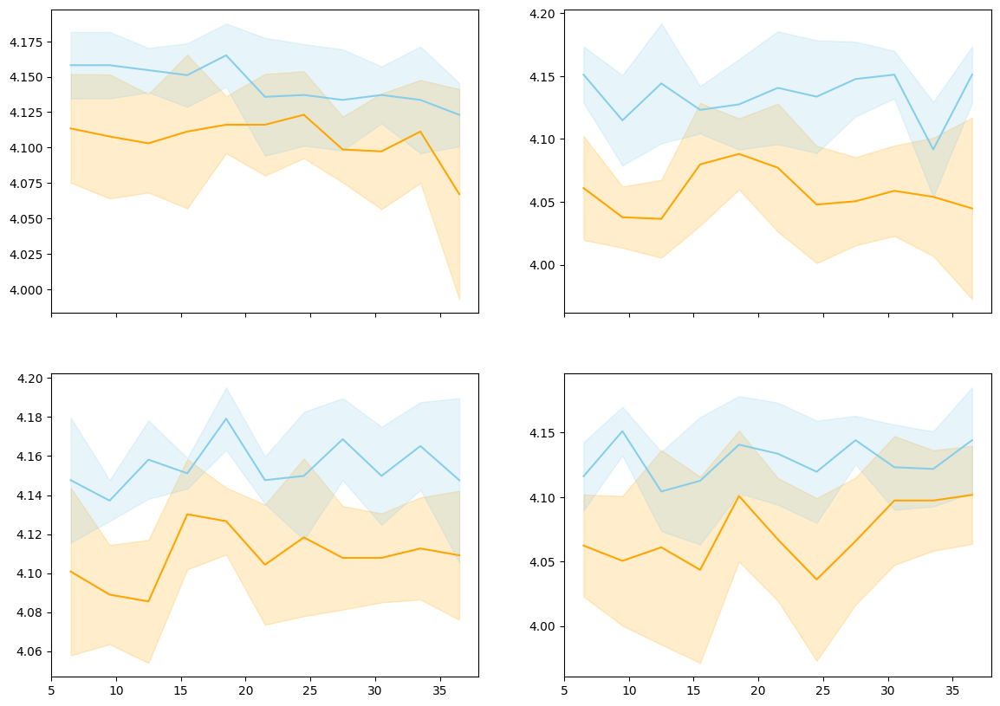

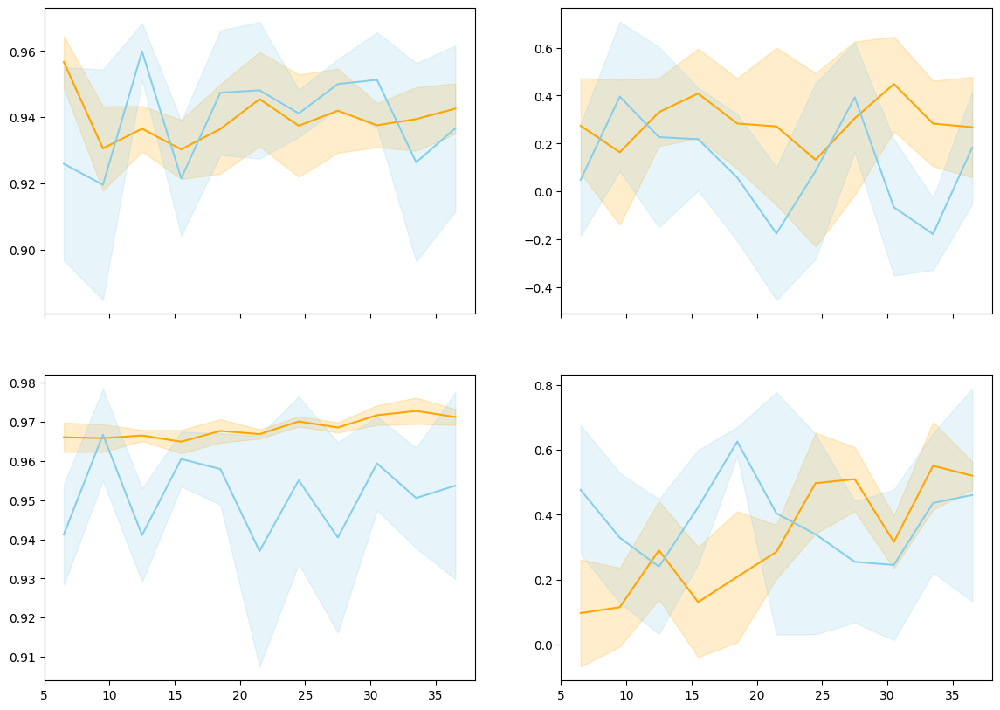

In [ ]:
ros = [0.5, 0.7, 1.0]
wind_speeds = [10, 20]
colors = ['orange', 'skyblue']

fontsize = 13

# axis intervals

ro_data = results_df[
    results_df["name"].str.startswith(f"{ro}ro_")
]

# X-axis: radius
x_min = ro_data["radius"].min()
x_max = ro_data["radius"].max()


# --------------------------------------------------
# MI range
# Include mean +/- std
# --------------------------------------------------

mi_lower = (
    ro_data["mutual_information_mean"]
    - ro_data["mutual_information_std"]
)

mi_upper = (
    ro_data["mutual_information_mean"]
    + ro_data["mutual_information_std"]
)

mi_min = mi_lower.min()
mi_max = mi_upper.max()


# --------------------------------------------------
# PC range
# Include mean +/- std
# --------------------------------------------------

pc_lower = (
    ro_data["pearson_correlation_mean"]
    - ro_data["pearson_correlation_std"]
)

pc_upper = (
    ro_data["pearson_correlation_mean"]
    + ro_data["pearson_correlation_std"]
)

pc_min = pc_lower.min()
pc_max = pc_upper.max()


for ro in ros:

    # Create MI and PC figures

    fig_mi, axes_mi = plt.subplots(
        2, 2,
        figsize=(14, 10),
        sharex=True
    )

    fig_pc, axes_pc = plt.subplots(
        2, 2,
        figsize=(14, 10),
        sharex=True
    )

    for i, ao in enumerate(["int", "pred"]):

        for k, ws in enumerate(wind_speeds):

            color = colors[k]

            # --------------------------------------------------
            # Raw
            # --------------------------------------------------

            name_raw = f"{ro}ro_{ws}ws_{ao}"

            data_raw = results_df[results_df["name"] == name_raw]


            # --------------------------------------------------
            # Mean-subtracted
            # --------------------------------------------------

            name_sub = f"{ro}ro_{ws}ws_{ao}_meam-sub"

            data_sub = results_df[results_df["name"] == name_sub]


            # --------------------------------------------------
            # MI: RAW
            # --------------------------------------------------

            ax = axes_mi[i, 0]

            ax.plot(
                data_raw["radius"],
                data_raw["mutual_information_mean"],
                color=color,
                label=f"{ws} m/s"
            )

            ax.fill_between(
                data_raw["radius"],
                data_raw["mutual_information_mean"]
                - data_raw["mutual_information_std"],
                data_raw["mutual_information_mean"]
                + data_raw["mutual_information_std"],
                color=color,
                alpha=0.2
            )


            # --------------------------------------------------
            # MI: MEAN-SUBTRACTED
            # --------------------------------------------------

            ax = axes_mi[i, 1]

            ax.plot(
                data_sub["radius"],
                data_sub["mutual_information_mean"],
                color=color,
                label=f"{ws} m/s"
            )

            ax.fill_between(
                data_sub["radius"],
                data_sub["mutual_information_mean"]
                - data_sub["mutual_information_std"],
                data_sub["mutual_information_mean"]
                + data_sub["mutual_information_std"],
                color=color,
                alpha=0.2
            )


            # --------------------------------------------------
            # PC: RAW
            # --------------------------------------------------

            ax = axes_pc[i, 0]

            ax.plot(
                data_raw["radius"],
                data_raw["pearson_correlation_mean"],
                color=color,
                label=f"{ws} m/s"
            )

            ax.fill_between(
                data_raw["radius"],
                data_raw["pearson_correlation_mean"]
                - data_raw["pearson_correlation_std"],
                data_raw["pearson_correlation_mean"]
                + data_raw["pearson_correlation_std"],
                color=color,
                alpha=0.2
            )


            # --------------------------------------------------
            # PC: MEAN-SUBTRACTED
            # --------------------------------------------------

            ax = axes_pc[i, 1]

            ax.plot(
                data_sub["radius"],
                data_sub["pearson_correlation_mean"],
                color=color,
                label=f"{ws} m/s"
            )

            ax.fill_between(
                data_sub["radius"],
                data_sub["pearson_correlation_mean"]
                - data_sub["pearson_correlation_std"],
                data_sub["pearson_correlation_mean"]
                + data_sub["pearson_correlation_std"],
                color=color,
                alpha=0.2
            )

    for ax in axes_mi.flat:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(mi_min, mi_max)
        ax.grid(alpha=0.3)

    for ax in axes_pc.flat:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(pc_min, pc_max)
        ax.grid(alpha=0.3)
        
    # ==========================================================
    # Formatting MI figure
    # ==========================================================

    axes_mi[0, 0].set_title("Raw", fontsize=fontsize + 2)
    axes_mi[0, 1].set_title("Mean-subtracted", fontsize=fontsize + 2)

    axes_mi[0, 0].set_ylabel(
        "Integrative\nMutual Information",
        fontsize=fontsize
    )

    axes_mi[1, 0].set_ylabel(
        "Predictive\nMutual Information",
        fontsize=fontsize
    )

    axes_mi[1, 0].set_xlabel(
        "Separation from the center (pixels)",
        fontsize=fontsize
    )

    axes_mi[1, 1].set_xlabel(
        "Separation from the center (pixels)",
        fontsize=fontsize
    )

    for ax in axes_mi.flat:
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=fontsize - 1)

    axes_mi[0, 0].legend(fontsize=fontsize)
    axes_mi[1, 0].legend(fontsize=fontsize)

    fig_mi.suptitle(
        f"Mutual Information — {ro}ro",
        fontsize=fontsize + 4
    )

    fig_mi.tight_layout()


    # ==========================================================
    # Formatting PC figure
    # ==========================================================

    axes_pc[0, 0].set_title("Raw", fontsize=fontsize + 2)
    axes_pc[0, 1].set_title("Mean-subtracted", fontsize=fontsize + 2)

    axes_pc[0, 0].set_ylabel(
        "Integrative\nPearson Correlation",
        fontsize=fontsize
    )

    axes_pc[1, 0].set_ylabel(
        "Predictive\nPearson Correlation",
        fontsize=fontsize
    )

    axes_pc[1, 0].set_xlabel(
        "Separation from the center (pixels)",
        fontsize=fontsize
    )

    axes_pc[1, 1].set_xlabel(
        "Separation from the center (pixels)",
        fontsize=fontsize
    )

    for ax in axes_pc.flat:
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=fontsize - 1)

    axes_pc[0, 0].legend(fontsize=fontsize)
    #axes_pc[1, 0].legend(fontsize=fontsize)

    fig_pc.suptitle(
        f"Pearson Correlation — {ro}ro",
        fontsize=fontsize + 4
    )

    fig_pc.tight_layout()


plt.show()


Text(0, 0.5, 'y [pixel]')

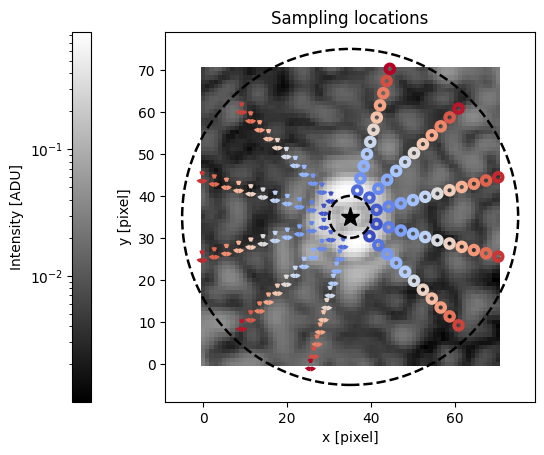

In [ ]:
(
    (x1, y1),
    left_int,
    (x2, y2),
    symmetric_int,
    radii
) = symmetric_intensities(
    data_cube[:, crop:-crop, crop:-crop],
    angle,
    inner_rad,
    outer_rad,
    dr=dr,
    photometry_radius=photometry_radius,
    
)
aperture_radius = 1.0
# ========================================================
# COLORMAP
# ========================================================

cmap = plt.get_cmap("coolwarm")

size = len(radii) * len(angle) if isinstance(angle, list) else len(radii)

colors = [
    cmap(i / max(size - 1, 1))
    for i in range(size)
]

# ========================================================
# IMAGE
# ========================================================

image = data_cube[
    0,
    crop:-crop,
    crop:-crop,
]

cy, cx = center_subpixel(image)

positive_image = image[image > 0]

image_norm = LogNorm(
    vmin=positive_image.min(),
    vmax=positive_image.max(),
)

fig, ax_img = plt.subplots()
im = ax_img.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=image_norm,
)

cbar_img = ax_img.figure.colorbar(
    im,
    ax=ax_img,
    fraction=0.046,
    pad=0.15,
    location="left",
)

cbar_img.set_label("Intensity [ADU]")

# Center
ax_img.plot(
    cx,
    cy,
    marker="*",
    markersize=14,
    markerfacecolor="black",
    markeredgecolor="black",
    linestyle="None",
    zorder=20,
)

# Outer radius
ax_img.add_patch(
    Circle(
        (cx, cy),
        outer_rad,
        fill=False,
        edgecolor="black",
        linewidth=1.8,
        linestyle="--",
        zorder=10,
    )
)

# Inner radius
ax_img.add_patch(
    Circle(
        (cx, cy),
        inner_rad,
        fill=False,
        edgecolor="black",
        linewidth=1.8,
        linestyle="--",
        zorder=10,
    )
)

# ========================================================
# APERTURES
# ========================================================

for j, (xx, yy) in enumerate(zip(x1, y1)):

    color = colors[j]

    # Selected side
    ax_img.add_patch(
        Circle(
            (xx, yy),
            aperture_radius,
            fill=False,
            edgecolor=color,
            linewidth=3,
        )
    )

    # Symmetric side
    ax_img.add_patch(
        Circle(
            (x2[j], y2[j]),
            aperture_radius,
            fill=False,
            edgecolor=color,
            linewidth=3.0,
            linestyle=":",
        )
    )

ax_img.set_title("Sampling locations")
ax_img.set_xlabel("x [pixel]")
ax_img.set_ylabel("y [pixel]")

# Saved best Contrast Curve

In [2]:
raw_contrast = pd.HDFStore('/home/aosimul/noah/data/ghost_images/10_20ws_2/raw_contrast.h5','r')
all_best = pd.HDFStore('/home/aosimul/noah/src/pipeline_ADI/results/contrast/overall_best.h5','r')
all_best.info()
all_best.keys()

['/60_deg_coro_10r0_20windspeed_int',
 '/60_deg_coro_10r0_20windspeed_pred',
 '/coro_10r0_10windspeed_1_pred',
 '/coro_10r0_10windspeed_2_pred',
 '/coro_10r0_10windspeed_3_pred',
 '/coro_10r0_10windspeed_int',
 '/coro_10r0_10windspeed_pred',
 '/coro_10r0_20windspeed_1_pred',
 '/coro_10r0_20windspeed_2_pred',
 '/coro_10r0_20windspeed_3_pred',
 '/coro_10r0_20windspeed_int',
 '/coro_10r0_20windspeed_pred',
 '/coro_5r0_10windspeed_1_pred',
 '/coro_5r0_10windspeed_2_pred',
 '/coro_5r0_10windspeed_3_pred',
 '/coro_5r0_10windspeed_int',
 '/coro_5r0_10windspeed_pred',
 '/coro_5r0_20windspeed_1_pred',
 '/coro_5r0_20windspeed_2_pred',
 '/coro_5r0_20windspeed_3_pred',
 '/coro_5r0_20windspeed_int',
 '/coro_5r0_20windspeed_pred',
 '/coro_7r0_10windspeed_1_pred',
 '/coro_7r0_10windspeed_2_pred',
 '/coro_7r0_10windspeed_3_pred',
 '/coro_7r0_10windspeed_int',
 '/coro_7r0_10windspeed_pred',
 '/coro_7r0_20windspeed_1_pred',
 '/coro_7r0_20windspeed_2_pred',
 '/coro_7r0_20windspeed_3_pred',
 '/coro_7r0_20

In [21]:
all_best['/coro_5r0_20windspeed_1_pred']

,best_contrast,best_PCA,cADI_contrast
separation [FWHM],,,
1.0,0.000611,65,0.001345
2.0,0.000049,30,0.000130
3.0,0.000011,35,0.000042
4.0,0.000005,5,0.000023
5.0,0.000003,1,0.000010
6.0,0.000003,140,0.000011
7.0,0.000007,140,0.000044
8.0,0.000017,125,0.000094
9.0,0.000013,110,0.000071


In [3]:
raw_contrast.keys()

['/pred_10ro_10ws_3',
 '/pred_10ro_20ws_3',
 '/pred_5ro_10ws_3',
 '/pred_5ro_20ws_3',
 '/pred_7ro_10ws_3',
 '/pred_7ro_20ws_3',
 '/psf_pred_10ro_10ws_1',
 '/psf_pred_10ro_10ws_2',
 '/psf_pred_10ro_20ws_1',
 '/psf_pred_10ro_20ws_2',
 '/psf_pred_5ro_10ws_1',
 '/psf_pred_5ro_10ws_2',
 '/psf_pred_5ro_20ws_1',
 '/psf_pred_5ro_20ws_2',
 '/psf_pred_7ro_10ws_1',
 '/psf_pred_7ro_10ws_2',
 '/psf_pred_7ro_20ws_1',
 '/psf_pred_7ro_20ws_2']

In [19]:
raw_contrast['/pred_7ro_20ws_3'] 

,,raw_contrast
pixel_rad,pixel_rad_fwhm,
0,0,98.463236
1,1,76.832011
2,2,41.652706
3,3,28.621912
4,4,43.301010
...,...,...
73,73,9.466848
74,74,8.821157
75,75,8.451393


In [23]:
#asuming they all have the same index I average the results of the 3 batches
avr_best = {}
count  = [1]
for ro in [0.7, 1.0, 0.5]:
    for ws in [20, 10]:
        name = f'pred_{ro*10:.0f}ro_{ws}ws'

        best_contrast = np.mean([
            all_best[f'/{name}_{c}']['best_contrast']
            for c in count
        ], axis = 0)

        best_contrast_std = np.sqrt(np.sum([
            all_best[f'/{name}_{c}']['best_contrast_std']**2
            for c in count
        ], axis=0))

        cADI_contrast = np.mean([
            all_best[f'/{name}_{c}']['cADI_contrast']
            for c in count
        ], axis = 0)

        cADI_contrast_std = np.sqrt(np.sum([
            all_best[f'/{name}_{c}']['cADI_contrast_std']**2
            for c in count
        ], axis=0))

        # All counts have the same index, so take it from the first one
        index = all_best[f'/{name}_{count[0]}'].index

        avr_best[name] = {
            'best_contrast': pd.Series(best_contrast, index=index),
            'best_contrast_std': pd.Series(best_contrast_std, index=index),
            'cADI_contrast': pd.Series(cADI_contrast, index=index),
            'cADI_contrast_std': pd.Series(cADI_contrast_std, index=index)
        }
avr_best

{'pred_7ro_20ws': {'best_contrast': pixel_rad  pixel_rad_fwhm
  1.0        4.828985          0.000898
  2.0        9.657970          0.000107
  3.0        14.486955         0.000030
  4.0        19.315940         0.000015
  5.0        24.144924         0.000009
  6.0        28.973909         0.000011
  7.0        33.802894         0.000018
  8.0        38.631879         0.000044
  9.0        43.460864         0.000032
  10.0       48.289849         0.000026
  11.0       53.118834         0.000023
  dtype: float64,
  'best_contrast_std': pixel_rad  pixel_rad_fwhm
  1.0        4.828985          0.000195
  2.0        9.657970          0.000014
  3.0        14.486955         0.000002
  4.0        19.315940         0.000001
  5.0        24.144924         0.000001
  6.0        28.973909         0.000002
  7.0        33.802894         0.000002
  8.0        38.631879         0.000003
  9.0        43.460864         0.000005
  10.0       48.289849         0.000004
  11.0       53.118834         

In [26]:
avr_best['pred_7ro_20ws']

{'best_contrast': pixel_rad  pixel_rad_fwhm
 1.0        4.828985          0.000898
 2.0        9.657970          0.000107
 3.0        14.486955         0.000030
 4.0        19.315940         0.000015
 5.0        24.144924         0.000009
 6.0        28.973909         0.000011
 7.0        33.802894         0.000018
 8.0        38.631879         0.000044
 9.0        43.460864         0.000032
 10.0       48.289849         0.000026
 11.0       53.118834         0.000023
 dtype: float64,
 'best_contrast_std': pixel_rad  pixel_rad_fwhm
 1.0        4.828985          0.000195
 2.0        9.657970          0.000014
 3.0        14.486955         0.000002
 4.0        19.315940         0.000001
 5.0        24.144924         0.000001
 6.0        28.973909         0.000002
 7.0        33.802894         0.000002
 8.0        38.631879         0.000003
 9.0        43.460864         0.000005
 10.0       48.289849         0.000004
 11.0       53.118834         0.000004
 dtype: float64,
 'cADI_contrast'

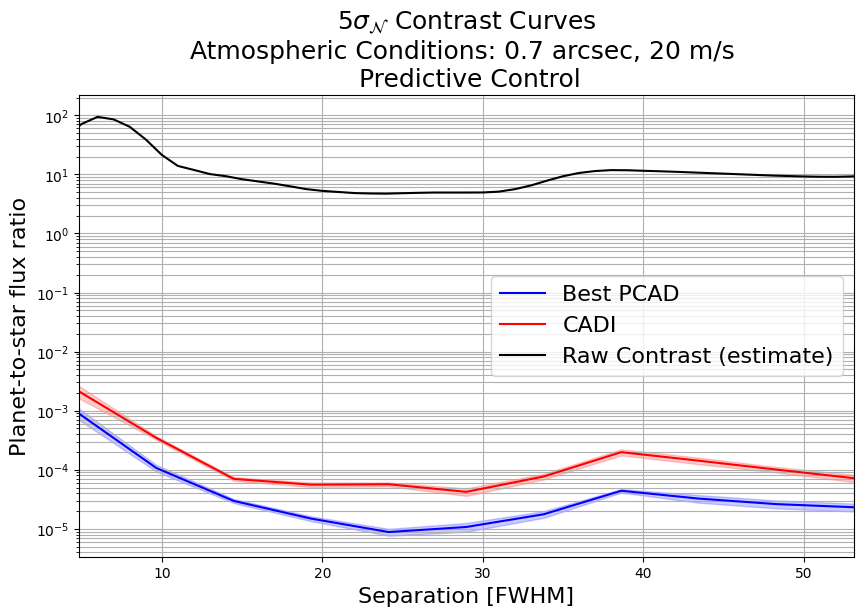

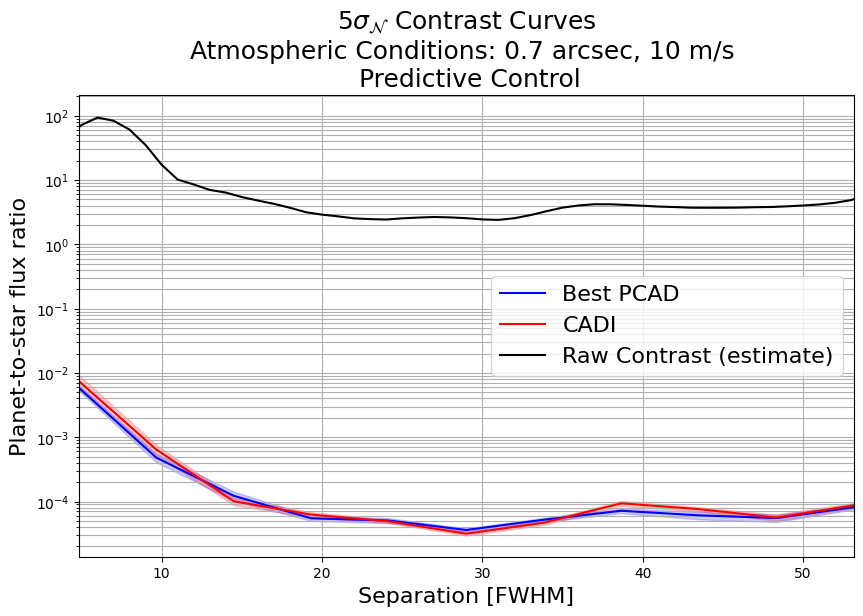

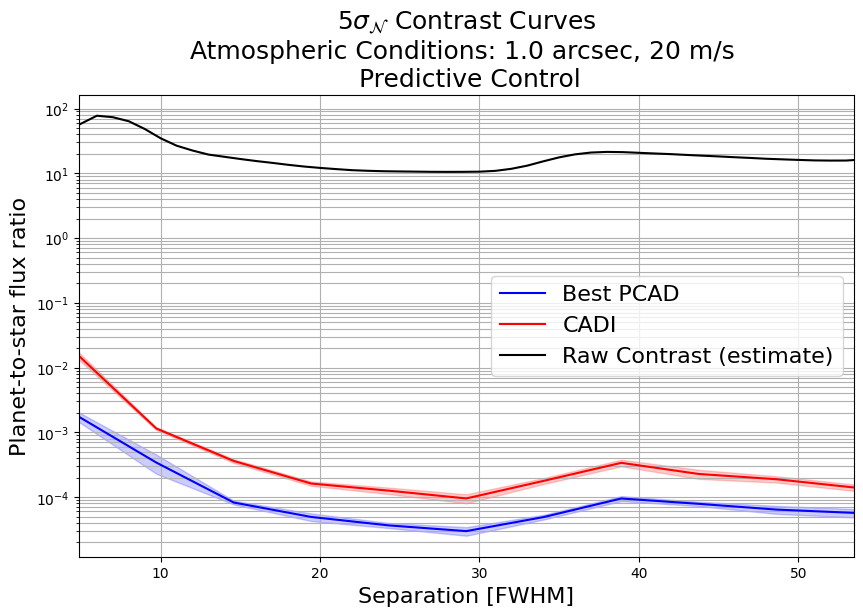

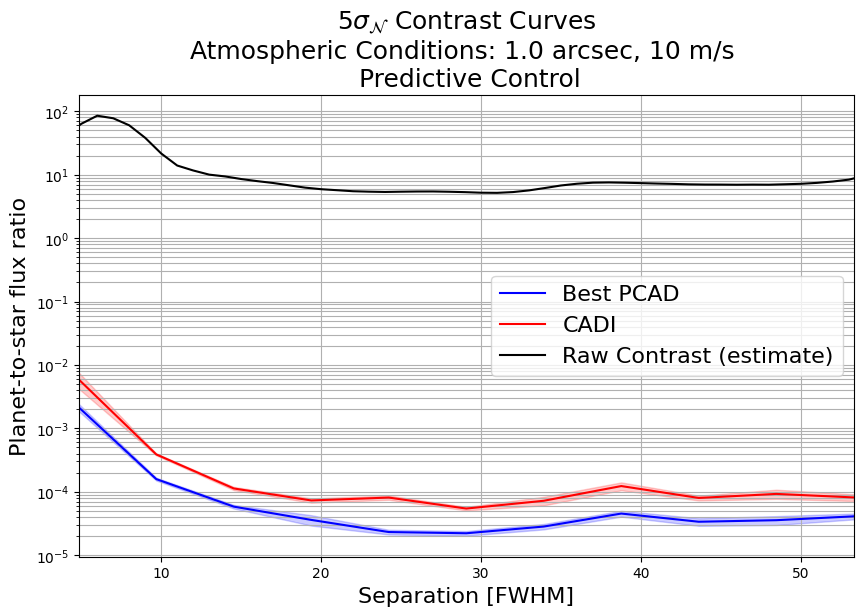

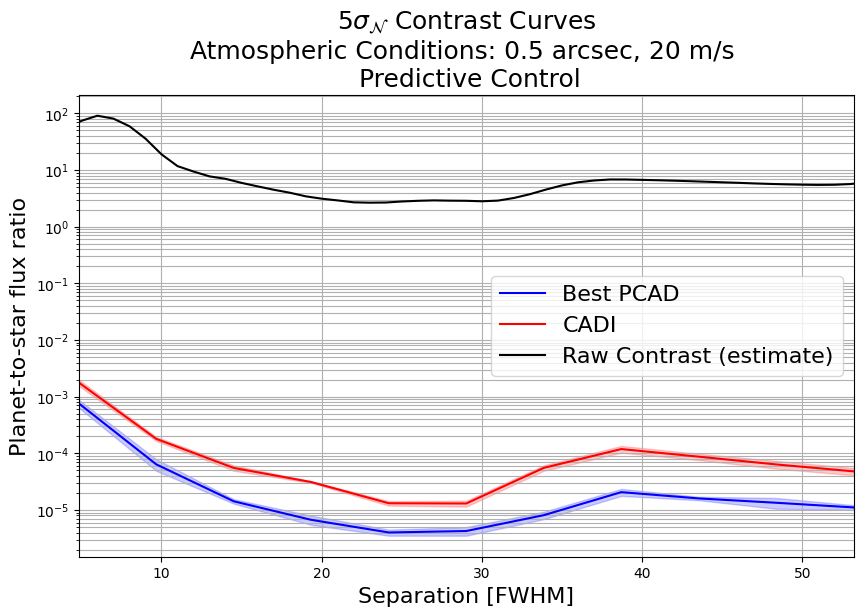

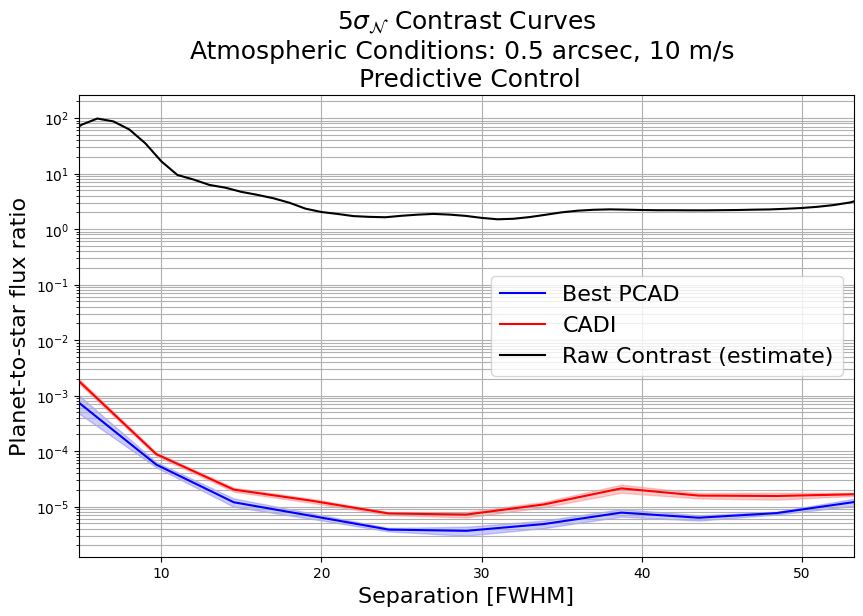

In [28]:
plt.close('all')
for ro in [0.7, 1.0, 0.5]:
    for ws in [20, 10]:
        name = f'coro_{ro*10:.0f}r0_{ws}windspeed'
        name_ = f'pred_{ro*10:.0f}ro_{ws}ws'
        df =  avr_best[name_]
        x = df['best_contrast'].index.get_level_values('pixel_rad_fwhm')
        rw = raw_contrast[f'/pred_{ro*10:.0f}ro_{ws}ws_3']
        plt.figure(figsize = (10,6))
        plt.plot(x, df['best_contrast'], color = 'blue', label = 'Best PCAD')
        plt.plot(x, df['cADI_contrast'], color = 'red', label = 'CADI')
        plt.plot(rw['raw_contrast'].index.get_level_values('pixel_rad_fwhm'), rw['raw_contrast'], color = 'black', label = 'Raw Contrast (estimate)')
        plt.fill_between(x, df['best_contrast'] - df['best_contrast_std'], df['best_contrast'] + df['best_contrast_std'], color = 'blue', alpha = 0.2)
        plt.fill_between(x, df['cADI_contrast'] - df['cADI_contrast_std'], df['cADI_contrast'] + df['cADI_contrast_std'], color = 'red', alpha = 0.2)
        plt.yscale('log')
        plt.title(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" + f"\nAtmospheric Conditions: {ro} arcsec, {ws} m/s \n Predictive Control", size=18)
        plt.grid( which= 'both')
        plt.ylabel(r"Planet-to-star flux ratio", size=16)
        plt.xlabel(r"Separation [FWHM]", size=16)
        plt.xlim(min(x), max(x))
        plt.legend(fontsize = 16)


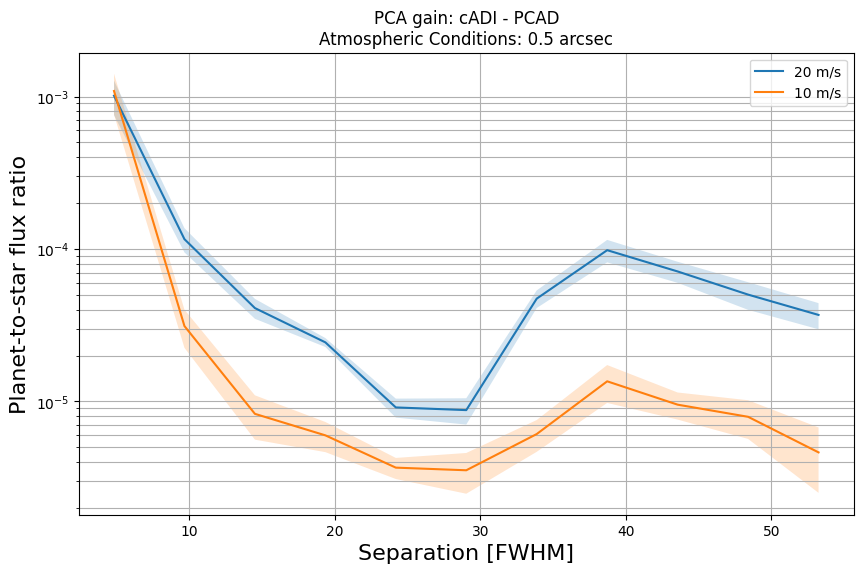

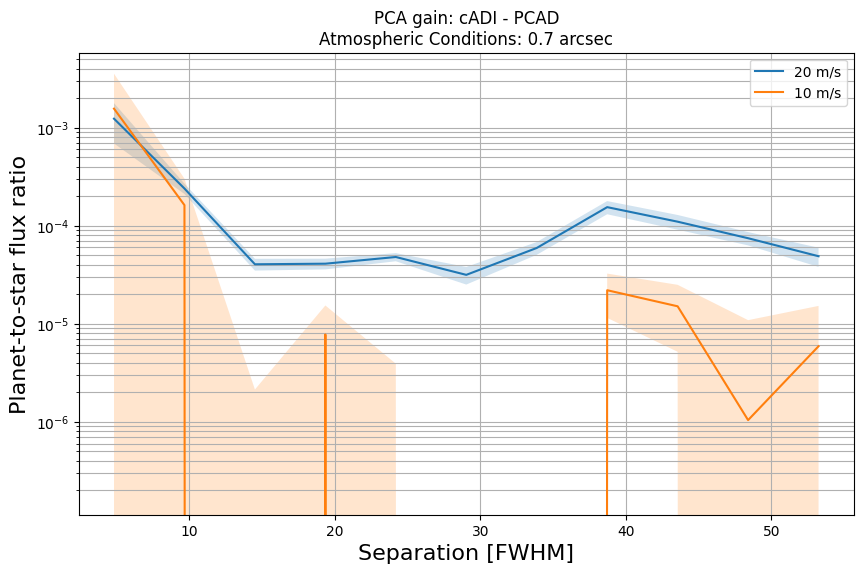

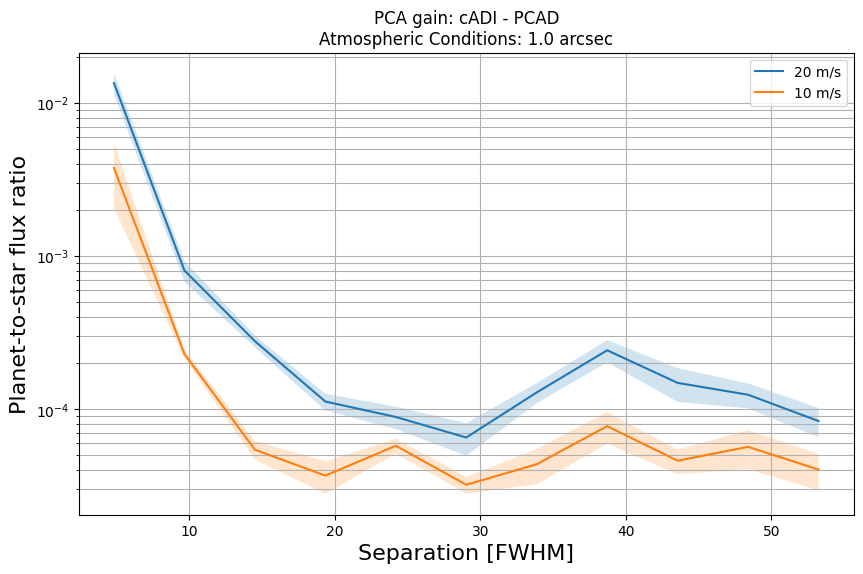

In [31]:
plt.close('all')
for ro in [0.5, 0.7, 1.0]:
    plt.figure(figsize = (10,6))
    for ws in [20, 10]:
        name = f'coro_{ro*10:.0f}r0_{ws}windspeed'
        name = f'pred_{ro*10:.0f}ro_{ws}ws'
        df =  avr_best[name]
        #rw = raw_contrast[f'/pred_{ro*10:.0f}ro_{ws}ws_1']
        gain =  df['cADI_contrast'] - df['best_contrast']
        gain_std = (df['best_contrast_std']**2 + df['cADI_contrast_std']**2)**0.5
        plt.plot(x, gain, label = f'{ws} m/s')
        plt.fill_between(x, gain - gain_std, gain + gain_std, alpha = 0.2)
    plt.yscale('log')
    plt.title(r"PCA gain: cADI - PCAD" + f"\nAtmospheric Conditions: {ro} arcsec")
    plt.grid( which= 'both')
    plt.ylabel(r"Planet-to-star flux ratio", size=16)
    plt.xlabel(r"Separation [FWHM]", size=16)
    #plt.xlim(min(df['cADI_contrast'].index), max(df['cADI_contrast'].index))
    plt.legend()